In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)

In [ ]:
# Financial parameters as requested
T = 0.25        # Time to maturity (in years)
K = 10.0        # Strike price
r = 0.1         # Risk-free interest rate
sigma = 0.4     # Volatility

# Domain boundaries
S_min = 0.0
S_max = 20.0
t_min = 0.0
t_max = T

In [ ]:
def build_model(num_hidden_layers=4, num_neurons=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal'))
    model.add(tf.keras.layers.Dense(1, activation=None))
    return model

pinn_N_model = build_model()
pinn_N_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def get_V(model, t, S):
    payoff = tf.maximum(S - K, 0.0)
    f = (T - t) * S
    N = model(tf.concat([t, S], axis=1))

    # Trial solution
    V = payoff + f * N

    return V


def loss_fn(model, t, S):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([t, S])
        with tf.GradientTape(persistent=True) as inner_tape:
            inner_tape.watch([t, S])
            V = get_V(model, t, S)
        V_t = inner_tape.gradient(V, t)
        V_S = inner_tape.gradient(V, S)
    V_SS = tape.gradient(V_S, S)
    del tape

    # Black-Scholes PDE residual
    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    pde_loss = tf.reduce_mean(tf.square(residual))
    N_bc = 1000
    t_upper = tf.random.uniform(shape=(N_bc, 1),
                                minval=t_min,
                                maxval=t_max,
                                dtype=DTYPE)
    S_upper = tf.fill((N_bc, 1), S_max)

    #PINN predicts at the upper boundary
    V_pred_upper = get_V(model, t_upper, S_upper)
    V_true_upper = S_max - K * tf.exp(-r * (T - t_upper))

    # Upper boundary penalty
    upper_bc_loss = tf.reduce_mean(tf.square(V_pred_upper - V_true_upper))
    lambda_bc = 1.0
    loss = pde_loss + lambda_bc * upper_bc_loss

    return loss



In [ ]:
N_collocation = 30000
t_col = tf.random.uniform(shape=(N_collocation, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_col = tf.random.uniform(shape=(N_collocation, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

In [ ]:
epochs = 10000
learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

@tf.function
def train_step(model):
    with tf.GradientTape() as tape:
        loss = loss_fn(model, t_col, S_col)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

for epoch in range(epochs):
    loss_value = train_step(pinn_N_model)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4e}")

Epoch 500, Loss: 1.0146e-02
Epoch 1000, Loss: 9.2398e-03
Epoch 1500, Loss: 8.6492e-03
Epoch 2000, Loss: 8.0292e-03
Epoch 2500, Loss: 7.5038e-03
Epoch 3000, Loss: 7.1066e-03
Epoch 3500, Loss: 6.6541e-03
Epoch 4000, Loss: 6.3398e-03
Epoch 4500, Loss: 5.9222e-03
Epoch 5000, Loss: 5.6071e-03
Epoch 5500, Loss: 5.3976e-03
Epoch 6000, Loss: 5.0269e-03
Epoch 6500, Loss: 5.0296e-03
Epoch 7000, Loss: 4.5164e-03
Epoch 7500, Loss: 4.2944e-03
Epoch 8000, Loss: 4.0994e-03
Epoch 8500, Loss: 3.9281e-03
Epoch 9000, Loss: 3.7833e-03
Epoch 9500, Loss: 3.6630e-03
Epoch 10000, Loss: 3.5754e-03


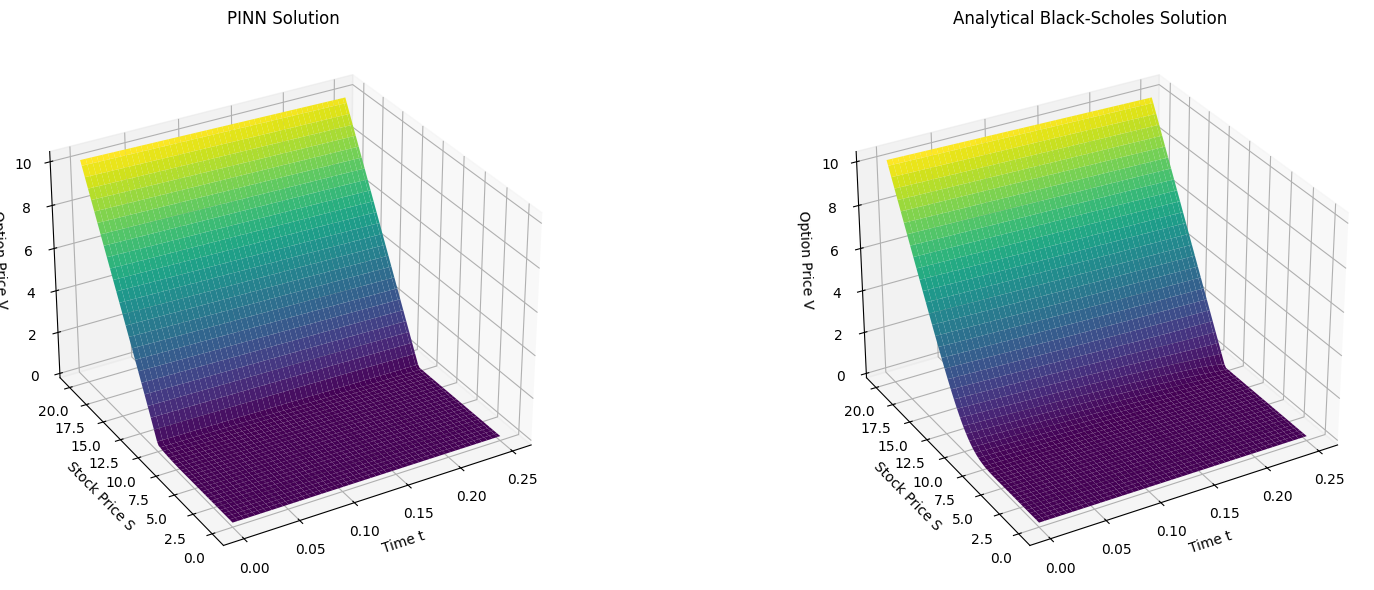

In [ ]:
def black_scholes_analytical_call(S, t, K, r, sigma, T):
    """Analytical solution for standard European call option."""
    if t == T:
        return np.maximum(S - K, 0)
    tau = T - t
    if tau <= 1e-8:
        return np.maximum(S - K, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    call_price = (S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2))
    return call_price

# Create a grid for plotting
S_plot = np.linspace(S_min, S_max, 100)
t_plot = np.linspace(t_min, t_max, 100)
S_grid, t_grid = np.meshgrid(S_plot, t_plot)

# Prepare grid points for prediction, ensuring they are rank-2 tensors
t_flat = tf.reshape(tf.constant(t_grid.flatten(), dtype=DTYPE), (-1, 1))
S_flat = tf.reshape(tf.constant(S_grid.flatten(), dtype=DTYPE), (-1, 1))

# Predict using the trained PINN by constructing the solution V
V_pred_flat = get_V(pinn_N_model, t_flat, S_flat)
V_pred = tf.reshape(V_pred_flat, S_grid.shape).numpy()

# Calculate analytical solution
V_analytical = np.zeros_like(S_grid)
for i in range(len(t_plot)):
    for j in range(len(S_plot)):
        s_val = S_grid[i, j] if S_grid[i, j] > 1e-8 else 1e-8
        V_analytical[i, j] = black_scholes_analytical_call(s_val, t_grid[i, j], K, r, sigma, T)

# Plotting
fig = plt.figure(figsize=(18, 6))

# PINN Solution
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(t_grid, S_grid, V_pred, cmap='viridis')
ax1.set_title('PINN Solution')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Stock Price S')
ax1.set_zlabel('Option Price V')
ax1.view_init(30, -120)

# Analytical Solution
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(t_grid, S_grid, V_analytical, cmap='viridis')
ax2.set_title('Analytical Black-Scholes Solution')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Stock Price S')
ax2.set_zlabel('Option Price V')
ax2.view_init(30, -120)

plt.tight_layout()
plt.show()

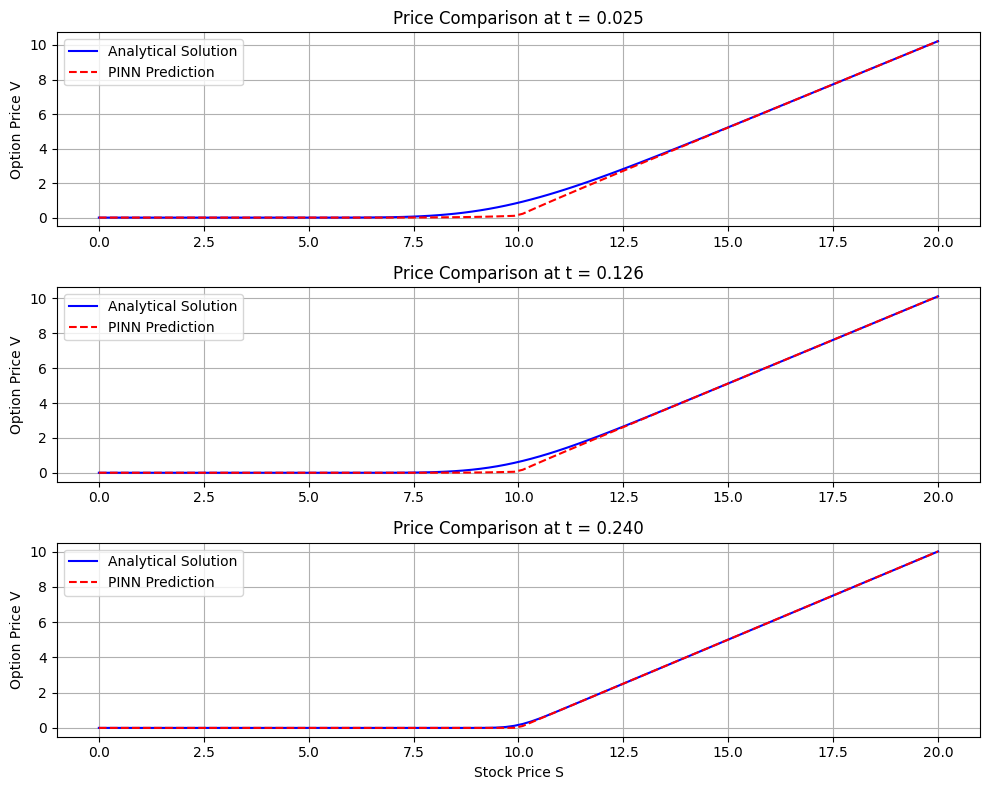

In [ ]:
plt.figure(figsize=(10, 8))
time_slices_indices = [10, 50, 95]
time_slices_values = [t_plot[i] for i in time_slices_indices]

# Create a subplot for each time slice
for i, time_idx in enumerate(time_slices_indices):
    plt.subplot(len(time_slices_indices), 1, i+1)

    # Plot analytical solution as a solid blue line
    plt.plot(S_plot, V_analytical[time_idx, :], 'b-', label='Analytical Solution')

    # Plot PINN prediction as a dashed red line
    plt.plot(S_plot, V_pred[time_idx, :], 'r--', label='PINN Prediction')

    plt.ylabel('Option Price V')
    plt.title(f'Price Comparison at t = {time_slices_values[i]:.3f}')
    plt.grid(True)
    plt.legend()

plt.xlabel('Stock Price S')
plt.tight_layout()
plt.show()

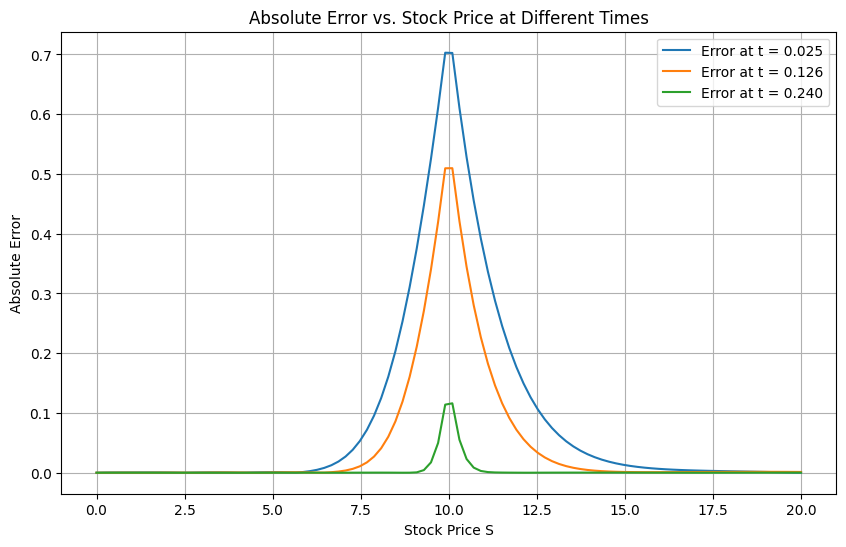

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the error curve for each time slice
for i, time_idx in enumerate(time_slices_indices):
    error = np.abs(V_pred[time_idx, :] - V_analytical[time_idx, :])
    plt.plot(S_plot, error, label=f'Error at t = {time_slices_values[i]:.3f}')

plt.title('Absolute Error vs. Stock Price at Different Times')
plt.xlabel('Stock Price S')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

  Upper Boundary Condition Error (Gonzalez Eq. 4)
  V(S_max, t) = S_max - K * exp(-r*(T-t))
  MAE       : 0.000809
  RMSE      : 0.000903
  Max Error : 0.001302
  Rel-L2    : 0.000089  (0.0089%)


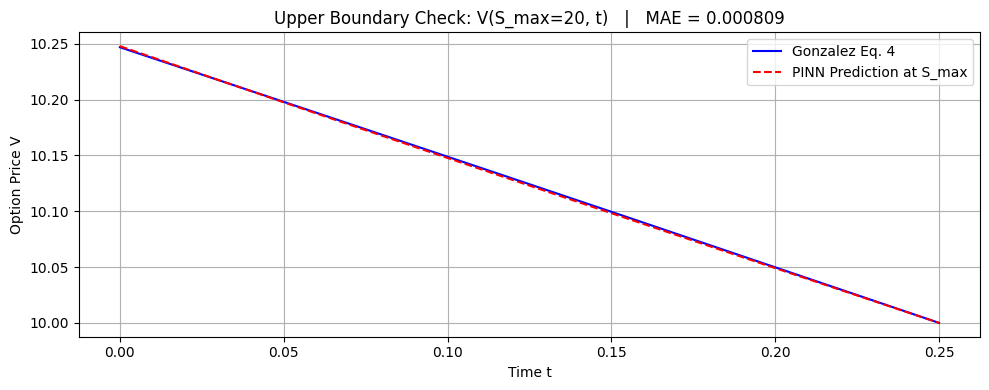

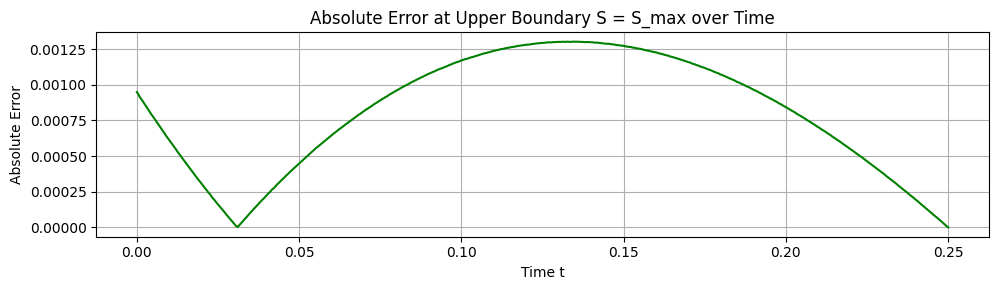

In [ ]:
t_check = np.linspace(t_min, t_max, 500).astype('float32').reshape(-1, 1)
S_check = np.full_like(t_check, S_max)

# PINN prediction at S = S_max
V_pinn_upper = get_V(
    pinn_N_model,
    tf.constant(t_check),
    tf.constant(S_check)
).numpy()

# Gonzalez true value at S = S_max
V_true_upper = S_max - K * np.exp(-r * (T - t_check))
diff = V_pinn_upper - V_true_upper

mae   = np.mean(np.abs(diff))
rmse  = np.sqrt(np.mean(diff**2))
max_e = np.max(np.abs(diff))
rel_l2 = np.linalg.norm(diff) / np.linalg.norm(V_true_upper)
print("  Upper Boundary Condition Error (Gonzalez Eq. 4)")
print("  V(S_max, t) = S_max - K * exp(-r*(T-t))")
print(f"  MAE       : {mae:.6f}")
print(f"  RMSE      : {rmse:.6f}")
print(f"  Max Error : {max_e:.6f}")
print(f"  Rel-L2    : {rel_l2:.6f}  ({rel_l2*100:.4f}%)")

# ── Plot: PINN vs True at S = S_max ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(t_check, V_true_upper, 'b-',  label='Gonzalez Eq. 4')
plt.plot(t_check, V_pinn_upper, 'r--', label='PINN Prediction at S_max')
plt.xlabel('Time t')
plt.ylabel('Option Price V')
plt.title(f'Upper Boundary Check: V(S_max=20, t)   |   MAE = {mae:.6f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Plot: absolute error along the upper boundary ────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(t_check, np.abs(diff), 'g-')
plt.xlabel('Time t')
plt.ylabel('Absolute Error')
plt.title('Absolute Error at Upper Boundary S = S_max over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ── Overall error across the full domain (same as your paper metrics) ─────────
diff_full = V_pred - V_analytical

mse_full   = np.mean(diff_full**2)
rmse_full  = np.sqrt(mse_full)
mae_full   = np.mean(np.abs(diff_full))
rel_l2_full = np.linalg.norm(diff_full) / np.linalg.norm(V_analytical)

print("  Full Domain Error (PINN vs Analytical BS)")
print(f"  MSE    : {mse_full:.6f}")
print(f"  RMSE   : {rmse_full:.6f}")
print(f"  MAE    : {mae_full:.6f}")
print(f"  Rel-L2 : {rel_l2_full:.6f}  ({rel_l2_full*100:.4f}%)")

  Full Domain Error (PINN vs Analytical BS)
  MSE    : 0.017234
  RMSE   : 0.131278
  MAE    : 0.049944
  Rel-L2 : 0.031193  (3.1193%)
